# The WorkFlow will be as follow 
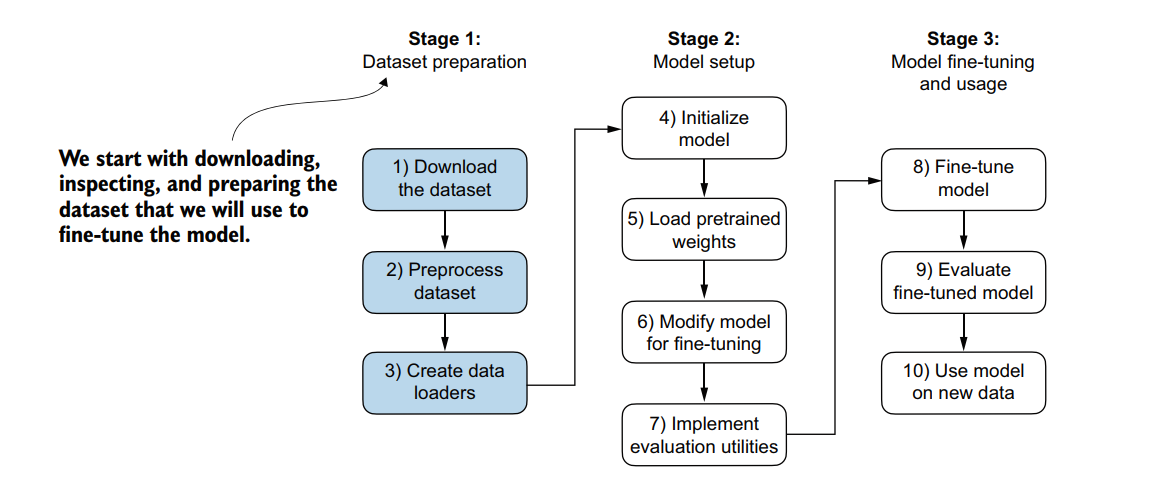

# Downloading the Dataset

In [1]:
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extract_path = "sms_spam_collection"
data_file_path = Path(extract_path) / "SMSSpamCollection.tsv"

def download_and_extract(url, zip_path, extract_path,data_file_path):
    
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return
    
    # download the zip file
    with urllib.request.urlopen(url) as response:
        with open(zip_path, 'wb') as out_file:
            out_file.write(response.read())

    # Extract the zip file
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    original_file_path = Path(extract_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File Downloaded and Saved to {data_file_path}")




In [2]:
download_and_extract(url, zip_path, extract_path,data_file_path)

sms_spam_collection\SMSSpamCollection.tsv already exists. Skipping download and extraction.


>> tsv : Tab separeted text file

# Load Dataset

- `header = None` : meaning the df dont have a header, so that pandas will put header row named [0,1]
- `names=['label', 'message']` : meaning replace the 0,1 names of header into `label, msg`

In [3]:
import pandas as pd

df = pd.read_csv(data_file_path, sep='\t', header=None, names=['label', 'message'])

In [4]:
df

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


### Examine the balncing of the dataset

In [6]:
df.label.value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

> Very Inbalanced 

## Undergo `undersampling` for ham class

### Calc the number of samples of `spam` class

In [7]:
num_spam = df[df['label'] == 'spam'].shape[0]
num_spam

747

### Subsetting from `Ham` class the same number as `Spam` class

In [8]:
ham_sub = df[df['label'] == 'ham'].sample(num_spam, random_state=42)
ham_sub

,label,message
3714,ham,If i not meeting ü all rite then i'll go home ...
1311,ham,"I.ll always be there, even if its just in spir..."
548,ham,"Sorry that took so long, omw now"
1324,ham,I thk 50 shd be ok he said plus minus 10.. Did...
3184,ham,Dunno i juz askin cos i got a card got 20% off...
...,...,...
4992,ham,We made it! Eta at taunton is 12:30 as planned...
3117,ham,Uncle Abbey! Happy New Year. Abiola
4975,ham,Aiyo u so poor thing... Then u dun wan 2 eat? ...
3505,ham,Will you be here for food


### Concat both `Subsets`

In [9]:
pd.concat([ham_sub, df[df['label'] == 'spam']])

,label,message
3714,ham,If i not meeting ü all rite then i'll go home ...
1311,ham,"I.ll always be there, even if its just in spir..."
548,ham,"Sorry that took so long, omw now"
1324,ham,I thk 50 shd be ok he said plus minus 10.. Did...
3184,ham,Dunno i juz askin cos i got a card got 20% off...
...,...,...
5537,spam,Want explicit SEX in 30 secs? Ring 02073162414...
5540,spam,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,spam,Had your contract mobile 11 Mnths? Latest Moto...
5566,spam,REMINDER FROM O2: To get 2.50 pounds free call...


### Reset Index
- `Drop = True` : Do not insert a new index col, replace the existing one

In [10]:
pd.concat([ham_sub, df[df['label'] == 'spam']]).reset_index(drop=True)

,label,message
0,ham,If i not meeting ü all rite then i'll go home ...
1,ham,"I.ll always be there, even if its just in spir..."
2,ham,"Sorry that took so long, omw now"
3,ham,I thk 50 shd be ok he said plus minus 10.. Did...
4,ham,Dunno i juz askin cos i got a card got 20% off...
...,...,...
1489,spam,Want explicit SEX in 30 secs? Ring 02073162414...
1490,spam,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
1491,spam,Had your contract mobile 11 Mnths? Latest Moto...
1492,spam,REMINDER FROM O2: To get 2.50 pounds free call...


In [11]:
def create_balanced_dataset(df):
    num_spam = df[df['label'] == 'spam'].shape[0]

    # sample from the Ham class 747 samples to match the number of Spam samples

    ham_subset = df[df['label'] == 'ham'].sample(num_spam, random_state=42)

    balanced_df = pd.concat([ham_subset, df[df['label'] == 'spam']]).reset_index(drop=True)

    return balanced_df

In [12]:
balanced_df = create_balanced_dataset(df)
balanced_df

,label,message
0,ham,If i not meeting ü all rite then i'll go home ...
1,ham,"I.ll always be there, even if its just in spir..."
2,ham,"Sorry that took so long, omw now"
3,ham,I thk 50 shd be ok he said plus minus 10.. Did...
4,ham,Dunno i juz askin cos i got a card got 20% off...
...,...,...
1489,spam,Want explicit SEX in 30 secs? Ring 02073162414...
1490,spam,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
1491,spam,Had your contract mobile 11 Mnths? Latest Moto...
1492,spam,REMINDER FROM O2: To get 2.50 pounds free call...


In [13]:
balanced_df.label.value_counts()

label
ham     747
spam    747
Name: count, dtype: int64

## Replace the `Spam`, `Ham` classes into 1 ,0

In [14]:
balanced_df.label = balanced_df.label.map({'ham': 0, 'spam': 1})
balanced_df

,label,message
0,0,If i not meeting ü all rite then i'll go home ...
1,0,"I.ll always be there, even if its just in spir..."
2,0,"Sorry that took so long, omw now"
3,0,I thk 50 shd be ok he said plus minus 10.. Did...
4,0,Dunno i juz askin cos i got a card got 20% off...
...,...,...
1489,1,Want explicit SEX in 30 secs? Ring 02073162414...
1490,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
1491,1,Had your contract mobile 11 Mnths? Latest Moto...
1492,1,REMINDER FROM O2: To get 2.50 pounds free call...


## Train Test Split

### Calc the indices of train from 0 to fraction we want 
- if we want 80% of data to be trained 
- Then the indices become from 0 : 80% of data

In [15]:
train_frac = 0.8
validation_frac = 0.1


train_end = int(train_frac * len(balanced_df))
train_end

1195

### Calc the indics of val data
- Starting from Train data + % we want to be used as validation
- if we want only 10% to be used as a validation 
- Then we start counting from 1195 + 10% of dataset

In [16]:
val_end = train_end + int(validation_frac * len(balanced_df))
val_end

1344

### Calc the indices of the test data
- indices starts after the stopping indices of val data

In [17]:
test_end = len(balanced_df)
test_end

1494

In [18]:
def random_split(df, train_frac , validation_frac):
    # frac =1 : returns 100% of the data, but shuffled
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)  # shuffle the dataset

    # calc split indices

    train_end = int(train_frac * len(df))

    validation_end = train_end + int(validation_frac * len(df))

    # split the dataset

    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]
    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)

    

In [19]:
train_df.shape, validation_df.shape, test_df.shape

((1045, 2), (149, 2), (300, 2))

### Save the `datasets`

In [20]:
os.makedirs("data", exist_ok=True)
train_df.to_csv("data/train.csv", index=None)
validation_df.to_csv("data/validation.csv", index=None)
test_df.to_csv("data/test.csv", index=None)



## Create Dataset

- **`With padding the shorter msgs to be eqaul to the longest msg`**
- this strategy better than trimming all longer msgs to meet the sequence of the shortest msg, which degenrate the performance 


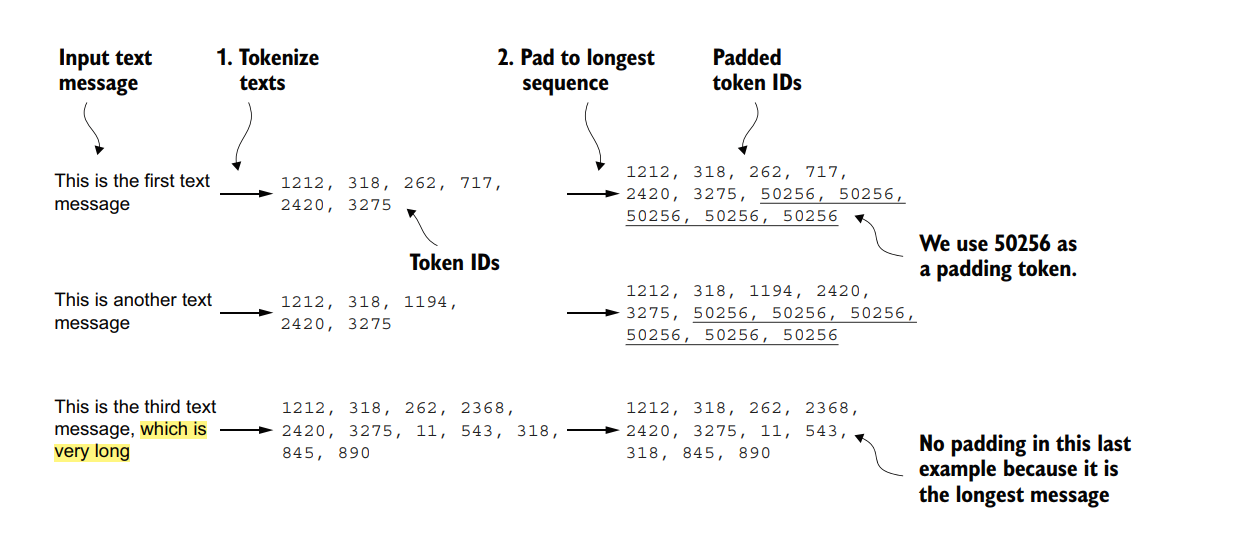

In [21]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))


[50256]


### Implement Dataset

In [22]:
first_msg = train_df[0:1]
first_msg

,label,message
0,0,K still are you loving me.


#### Extract the message 

In [23]:
first_msg["message"].values[0]

'K still are you loving me.'

In [24]:
import torch 
from torch.utils.data import Dataset, DataLoader


class SpamDataset(Dataset):
    def __init__(self,csv_file, tokenizer, max_length=None, pad_token = 50256):
        # Read the csv file
        self.data = pd.read_csv(csv_file)

        # Pretokenize the msgs

        self.encoded_texts = [tokenizer.encode(msg) for msg in self.data['message']]
        if max_length is None:
            self.max_length = self._longest_encoded_length()
        
        # Truncate the encoded texts to max_length
        else:
            self.max_length = max_length
            self.encoded_texts = [msg[:self.max_length] for msg in self.encoded_texts]

        # Pads the encoded texts to max_length

        self.encoded_texts = [ msg +[pad_token] * (self.max_length - len(msg)) for msg in self.encoded_texts]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data['label'][index]
        return (torch.tensor(encoded, dtype=torch.long), torch.tensor(label, dtype=torch.long))
    

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            if len(encoded_text) > max_length:
                max_length = len(encoded_text)
        return max_length

In [25]:
train_dataset = SpamDataset("data/train.csv",
                            tokenizer,
                            max_length=None,
                            )

#### Observe the max length of the `train dataset`

In [26]:
train_dataset.max_length

120

#### Padding the `Val` `Test` Dataset to match the `Training` Dataset

In [27]:
val_dataset = SpamDataset("data/validation.csv",
                            tokenizer,
                            max_length = train_dataset.max_length,
                            )

test_dataset = SpamDataset("data/test.csv",
                            tokenizer,
                            max_length = train_dataset.max_length,
                            )

## Create DataLoaders

In [28]:
from torch.utils.data import DataLoader


batch_size = 8
num_workers = 0
torch.manual_seed(123)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers,drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=num_workers)



### Maker sure everything is okay 
- Lets see a batch of `train_dataloader` and check the shapes of the inputs and labels

In [29]:
for msg, labels in train_loader:
    print("Batch of messages shape:", msg.shape)
    print("Batch of labels shape:", labels.shape)
    break

Batch of messages shape: torch.Size([8, 120])
Batch of labels shape: torch.Size([8])


> `each loader of 8 samples, each with 120 tokens`

In [30]:
print(f"{len(train_loader)} Training batches")
print(f"{len(val_loader)} Validation batches")
print(f"{len(test_loader)} Test batches")

130 Training batches
19 Validation batches
38 Test batches


## Init `GPT Model` with pretrained weight

In [31]:
BASE_CONFIG = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "drop_rate": 0.0,       # Dropout rate
    "qkv_bias": True        # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}


CHOOSE_MODEL = "gpt2-small (124M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
INPUT_PROMPT = "Every Efforts moves you"

In [32]:
BASE_CONFIG

{'vocab_size': 50257,
 'context_length': 1024,
 'drop_rate': 0.0,
 'qkv_bias': True,
 'emb_dim': 768,
 'n_layers': 12,
 'n_heads': 12}

#### Loading the pretrained `OPENAI` weights

In [89]:
from gpt import GPTModel

gpt = GPTModel(BASE_CONFIG)
gpt.load_state_dict(torch.load("gpt2-small-124M.pth"))



<All keys matched successfully>

In [90]:
from gpt_training import generate_text_sample , text_to_token, token_ids_to_text

t1 = "Every efforts moves you"
token_ids = generate_text_sample(
    model=gpt,
    idx = text_to_token(tokenizer, t1),
    max_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(tokenizer, token_ids))

Every efforts moves you forward.

The first step is to understand the world around you.


## Before starting the Fine-Tuning Process
- Lets test the model whtere it follows the instructions or not 

In [35]:
t2 = ("Is the Following text `spam`? Answer with 'yes' or 'no' :"
      "'You are a winner you have been specially "
      "Selected to receive $1000 cash or $2000 award'"
)
t2

"Is the Following text `spam`? Answer with 'yes' or 'no' :'You are a winner you have been specially Selected to receive $1000 cash or $2000 award'"

In [36]:
token_ids = generate_text_sample(
    model = gpt,
    idx = text_to_token(tokenizer, t2),
    max_tokens=25,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(tokenizer, token_ids))

Is the Following text `spam`? Answer with 'yes' or 'no' :'You are a winner you have been specially Selected to receive $1000 cash or $2000 award'

The following text is a list of the winners of the following awards:

The following text is a list of


> **`As we see, the model struggles to follow the instructions`**

## Adding A Classification Head 

### We will replace the last `out_head` of 50,257 with a simpler head of 2 classes 
- 0: Ham
- 1: Spam

In [37]:
gpt

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [38]:
gpt.out_head

Linear(in_features=768, out_features=50257, bias=False)

### Freeze all the layers




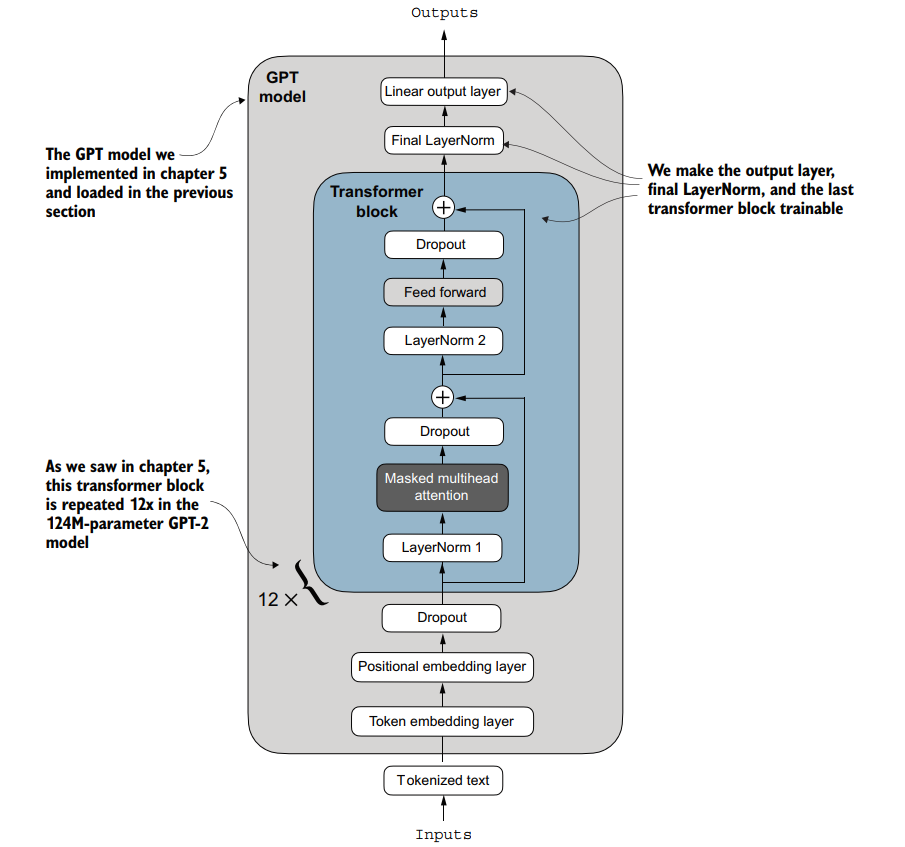

In [39]:
list(gpt.parameters())

[Parameter containing:
 tensor([[-0.1101, -0.0393,  0.0331,  ..., -0.1364,  0.0151,  0.0453],
         [ 0.0403, -0.0486,  0.0462,  ...,  0.0861,  0.0025,  0.0432],
         [-0.1275,  0.0479,  0.1841,  ...,  0.0899, -0.1297, -0.0879],
         ...,
         [-0.0445, -0.0548,  0.0123,  ...,  0.1044,  0.0978, -0.0695],
         [ 0.1860,  0.0167,  0.0461,  ..., -0.0963,  0.0785, -0.0225],
         [ 0.0514, -0.0277,  0.0499,  ...,  0.0070,  0.1552,  0.1207]],
        requires_grad=True),
 Parameter containing:
 tensor([[-1.8821e-02, -1.9742e-01,  4.0267e-03,  ..., -4.3044e-02,
           2.8267e-02,  5.4490e-02],
         [ 2.3959e-02, -5.3792e-02, -9.4879e-02,  ...,  3.4170e-02,
           1.0172e-02, -1.5573e-04],
         [ 4.2161e-03, -8.4764e-02,  5.4515e-02,  ...,  1.9745e-02,
           1.9325e-02, -2.1424e-02],
         ...,
         [-1.7987e-03,  1.6052e-03, -5.5103e-02,  ...,  1.3617e-02,
          -7.1805e-03,  3.7552e-03],
         [ 3.2105e-03,  1.5501e-03, -4.8944e-02,  

In [40]:
gpt.state_dict()

OrderedDict([('tok_emb.weight',
              tensor([[-0.1101, -0.0393,  0.0331,  ..., -0.1364,  0.0151,  0.0453],
                      [ 0.0403, -0.0486,  0.0462,  ...,  0.0861,  0.0025,  0.0432],
                      [-0.1275,  0.0479,  0.1841,  ...,  0.0899, -0.1297, -0.0879],
                      ...,
                      [-0.0445, -0.0548,  0.0123,  ...,  0.1044,  0.0978, -0.0695],
                      [ 0.1860,  0.0167,  0.0461,  ..., -0.0963,  0.0785, -0.0225],
                      [ 0.0514, -0.0277,  0.0499,  ...,  0.0070,  0.1552,  0.1207]])),
             ('pos_emb.weight',
              tensor([[-1.8821e-02, -1.9742e-01,  4.0267e-03,  ..., -4.3044e-02,
                        2.8267e-02,  5.4490e-02],
                      [ 2.3959e-02, -5.3792e-02, -9.4879e-02,  ...,  3.4170e-02,
                        1.0172e-02, -1.5573e-04],
                      [ 4.2161e-03, -8.4764e-02,  5.4515e-02,  ...,  1.9745e-02,
                        1.9325e-02, -2.1424e-02],
         

In [91]:
for param in gpt.parameters():
    param.requires_grad= False

### Now we Replace the final Output Layer

- This new NN by default, the `require_grad = True`

In [92]:
torch.manual_seed(123)
num_classes =2

gpt.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)


### Train the last transformer_block and norm layer to get better performance

In [83]:
gpt.trf_blocks[-1]

TransformerBlock(
  (att): MultiHeadAttention(
    (W_query): Linear(in_features=768, out_features=768, bias=True)
    (W_key): Linear(in_features=768, out_features=768, bias=True)
    (W_value): Linear(in_features=768, out_features=768, bias=True)
    (out_proj): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (ff): FeedForward(
    (layers): Sequential(
      (0): Linear(in_features=768, out_features=3072, bias=True)
      (1): GELU()
      (2): Linear(in_features=3072, out_features=768, bias=True)
    )
  )
  (norm1): LayerNorm()
  (norm2): LayerNorm()
  (drop_shortcut): Dropout(p=0.0, inplace=False)
)

In [84]:
list(gpt.final_norm.parameters())

[Parameter containing:
 tensor([1.3937e+00, 1.3731e+00, 1.8836e+00, 1.1671e+00, 1.2705e+00, 1.2475e+00,
         9.4018e+00, 1.4344e+00, 1.4503e+00, 1.1824e+00, 1.3919e+00, 1.2759e+00,
         1.2053e+00, 1.2929e+00, 1.2748e+00, 1.3452e+00, 1.5054e+00, 1.3699e+00,
         1.3397e+00, 2.3704e+00, 1.1360e+00, 1.2881e+00, 1.3444e+00, 1.4740e+00,
         1.2518e+00, 1.1974e+00, 1.4915e+00, 1.1609e+00, 1.2555e+00, 1.2280e+00,
         1.1815e+00, 1.1886e+00, 1.2202e+00, 1.2772e+00, 1.3262e+00, 1.6168e+00,
         1.3776e+01, 1.1846e+00, 1.2210e+00, 1.4546e+00, 1.1666e+00, 1.3136e+00,
         1.1418e+00, 1.2611e+00, 1.4753e+00, 1.2403e+00, 1.1722e+00, 1.1577e+00,
         1.3611e+00, 2.1232e+00, 1.2341e+00, 1.2302e+00, 1.7353e+00, 1.1526e+00,
         1.3276e+00, 1.8551e+00, 1.2905e+00, 1.3287e+00, 1.2126e+00, 1.5383e+00,
         1.3752e+00, 1.2050e+00, 1.4003e+00, 1.5696e+00, 7.7142e-03, 1.1823e+00,
         1.2125e+00, 1.2568e+00, 1.8465e+00, 1.1510e+00, 1.2910e+00, 1.1548e+00,
     

In [93]:
for param in gpt.trf_blocks[-1].parameters():
    param.requires_grad =True

for param in gpt.final_norm.parameters():
    param.requires_grad= True


### Using The model

In [86]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print(f"Input Tokens : {inputs}")
print(f"Shape of tokens : {inputs.shape}")

Input Tokens : tensor([[5211,  345,  423,  640]])
Shape of tokens : torch.Size([1, 4])


### Pass it to the model

In [49]:
with torch.no_grad():
    outputs = gpt(inputs)

print(f"\nOutputs : {outputs}\n")
print(f"Output Dimensions : {outputs.shape}")


Outputs : tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])

Output Dimensions : torch.Size([1, 4, 2])


>> This gives for each token, its logits of ham, spam
>> but we intersted in the last prediction not every token prediciton


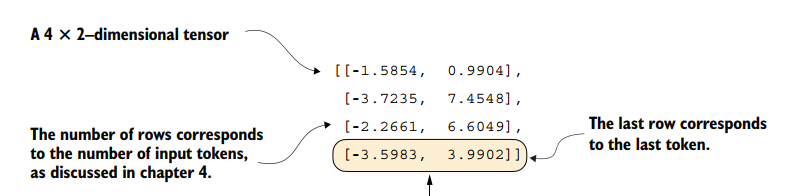

**`> We only intersted in the last token, since it gather information from its preeceding tokens, so that the prediction is more accurate`**

In [50]:
print(f"Last output token : {outputs[:,-1,:]}")

Last output token : tensor([[-3.5983,  3.9902]])


#### Obtaining class label

In [51]:
probas = torch.softmax(outputs[:,-1,:], dim=-1)
probas

tensor([[5.0598e-04, 9.9949e-01]])

In [52]:
print(f"Class Label : {torch.argmax(probas,dim=-1).item()}")

Class Label : 1


#### Shape of this label 

In [53]:
torch.argmax(probas,dim=-1).shape[0]

1

### Design the Loss function for 2 classes instead of 50,257

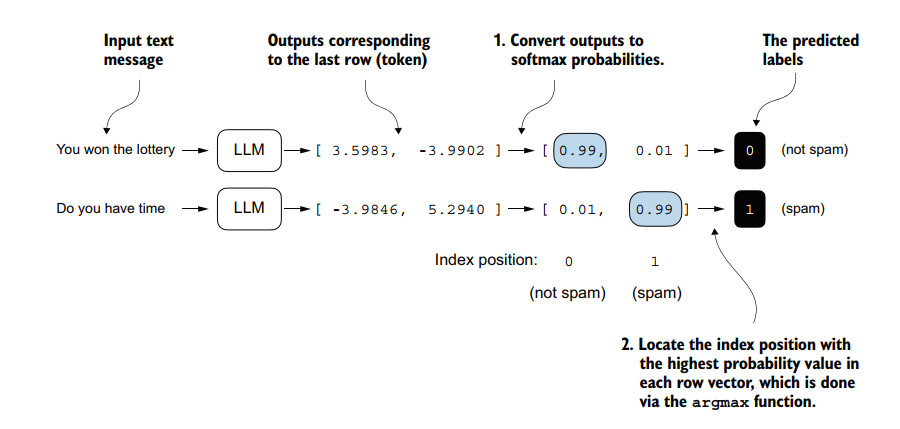

### Loss Function

In [54]:
a = torch.tensor([1,0,1,1,1,0])
b = torch.tensor([0,1,1,0,1,1])
c = (a == b).sum().item()
print(c)

2


In [55]:
def calc_acc_loader(data_loader, model, device, num_batches= None):
    model.eval()
    correct_predictions, num_examples = 0 , 0

    # If there is no num_batches assigned, calc the loss for all of them at once
    if num_batches is None:
        num_batches = len(data_loader)

    # this condition for safety, if user enter num_batches not realistic, it took the len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i , (input, target) in enumerate(data_loader):
        if i < num_batches:
            input = input.to(device)
            target = target.to(device)

            with torch.no_grad():
                logits = model(input)[:,-1,:] # last token only
            probas = torch.softmax(logits, dim=-1)
            predicted_label = torch.argmax(probas, dim=-1)
            num_examples += predicted_label.shape[0]

            # Compare Prediction between Boolean Tensors
            correct_predictions += (
            (predicted_label == target).sum().item()
            )

        else:
            break
    return correct_predictions / num_examples



#### Lets use the function

In [56]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpt.to(device)
torch.manual_seed(123)

train_acc = calc_acc_loader(train_loader, gpt, device, 10)
val_acc = calc_acc_loader(val_loader, gpt, device, 10)
test_acc = calc_acc_loader(test_loader, gpt, device, 10)

print(f"Training Accuracy without Training : {train_acc *100:.2f}%")
print(f"Validation Accuracy without Training : {val_acc *100:.2f}%")
print(f"Testing Accuracy without Training : {test_acc *100:.2f}%")

Training Accuracy without Training : 46.25%
Validation Accuracy without Training : 45.00%
Testing Accuracy without Training : 48.75%


> **`The accuracy prediction is near random prediction`**

### Loss function `Cross Entropy`


In [57]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)[:,-1,:]
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

### Loss Function Loader

In [70]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0
    if len(data_loader) ==0:
        return float("nan")

    elif num_batches is None:
        num_batches = len(data_loader)
    
    else:
        num_batches = min(num_batches , len(data_loader))

    for i , (input_batch, target_batch) in enumerate(data_loader):

        #print(f"Iteration : {i}")
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss

        else:
            break
    
    return total_loss / num_batches


#### Test the function 

In [71]:
with torch.no_grad():
    train_acc = calc_loss_loader(train_loader, gpt, device,5)
    val_acc = calc_loss_loader(val_loader, gpt, device, 5)
    test_acc = calc_loss_loader(test_loader, gpt, device, 5)

print(f"Training Loss without Training : {train_acc :.2f}")
print(f"Validation Loss without Training : {val_acc :.2f}")
print(f"Testing Loss without Training : {test_acc :.2f}")

Training Loss without Training : 2.05
Validation Loss without Training : 2.57
Testing Loss without Training : 2.33


## Training Function

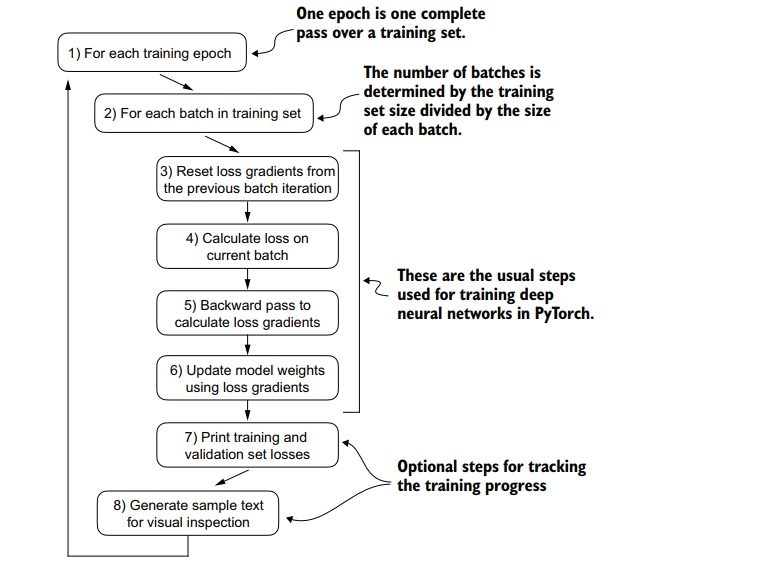

In [72]:
def evaluate_model(model, trian_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model,device ,num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


In [95]:
def train_classifier(model,train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen , global_step = 0 , -1

    model.to(device)

    for epoch in range(num_epochs):
        model.train()

        for input_batch,target_batch in train_loader:
            
            # remove any gradient accumulation
            optimizer.zero_grad()
            
            # calc loss
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            
            # Backprpagation
            loss.backward() 

            # update weights
            optimizer.step()

            examples_seen += input_batch.shape[0]
            global_step +=1


            # Evaluation step

            if global_step % eval_freq ==0 :
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)

                # Appending loss
                train_losses.append(train_loss)
                val_losses.append(val_loss)

                print(f"Ep {epoch+1} (step {global_step:06d}) "
                      f"Train Loss : {train_loss:.3f}, "
                      f"Val Loss : {val_loss:.3f}")
                
        # Calculating accuracy
        train_acc = calc_acc_loader(train_loader, model, device, eval_iter)
        val_acc = calc_acc_loader(val_loader, model, device, eval_iter)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Training Accuracy: {train_acc*100:.2f}%")
        print(f"Validation Accuracy: {val_acc*100:.2f}%")

    return train_losses, val_losses, train_accs, val_accs, examples_seen


### Init the optimizer

In [96]:
import time

start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(gpt.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5

train_losses, val_losses, train_accs, val_accs, example_seen = train_classifier(gpt, train_loader, val_loader, optimizer, device, num_epochs, eval_freq=50, eval_iter=5)

end_time = time.time()

exec_time_in_mins = (end_time - start_time) / 60
print(f"Training Completed in {exec_time_in_mins:.2f} minutes.")

Ep 1 (step 000000) Train Loss : 2.160, Val Loss : 2.374
Ep 1 (step 000050) Train Loss : 0.654, Val Loss : 0.631
Ep 1 (step 000100) Train Loss : 0.531, Val Loss : 0.566
Training Accuracy: 85.00%
Validation Accuracy: 75.00%
Ep 2 (step 000150) Train Loss : 0.572, Val Loss : 0.513
Ep 2 (step 000200) Train Loss : 0.283, Val Loss : 0.387
Ep 2 (step 000250) Train Loss : 0.548, Val Loss : 0.334
Training Accuracy: 87.50%
Validation Accuracy: 72.50%
Ep 3 (step 000300) Train Loss : 0.312, Val Loss : 0.323
Ep 3 (step 000350) Train Loss : 0.371, Val Loss : 0.241
Training Accuracy: 90.00%
Validation Accuracy: 92.50%
Ep 4 (step 000400) Train Loss : 0.115, Val Loss : 0.201
Ep 4 (step 000450) Train Loss : 0.034, Val Loss : 0.108
Ep 4 (step 000500) Train Loss : 0.409, Val Loss : 0.065
Training Accuracy: 97.50%
Validation Accuracy: 97.50%
Ep 5 (step 000550) Train Loss : 0.201, Val Loss : 0.052
Ep 5 (step 000600) Train Loss : 0.071, Val Loss : 0.055
Training Accuracy: 100.00%
Validation Accuracy: 97.50%
T

### Plotting the Classification loss

In [167]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, example_seen,train_values, val_values, label="loss"):

    fig, ax1 = plt.subplots(figsize=(7,4))

    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen , val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()
    # Create second axis for examples seen

    ax2 = ax1.twiny()
    ax2.plot(example_seen, train_values, alpha=0) #invisible line for aligining ticks
    ax2.set_xlabel("Examples seen")


    # adjust layout
    fig.tight_layout()

    plt.savefig(f"{label}-plot.pdf")
    plt.show()


In [102]:
len(train_losses)

13

In [155]:
epochs_tensor = torch.linspace(0, num_epochs , len(train_losses))
epochs_tensor

tensor([0.0000, 0.4167, 0.8333, 1.2500, 1.6667, 2.0833, 2.5000, 2.9167, 3.3333,
        3.7500, 4.1667, 4.5833, 5.0000])

In [156]:
example_seen_tensor = torch.linspace(0, example_seen, len(train_losses))
example_seen_tensor

tensor([   0.0000,  433.3333,  866.6667, 1300.0000, 1733.3334, 2166.6667,
        2600.0000, 3033.3333, 3466.6665, 3900.0000, 4333.3335, 4766.6665,
        5200.0000])

In [157]:
t_l = torch.stack(train_losses).to("cpu")
v_l = torch.stack(val_losses).to("cpu")

In [158]:
v_l

tensor([2.3735, 0.6308, 0.5658, 0.5130, 0.3872, 0.3335, 0.3226, 0.2408, 0.2009,
        0.1082, 0.0651, 0.0516, 0.0553])

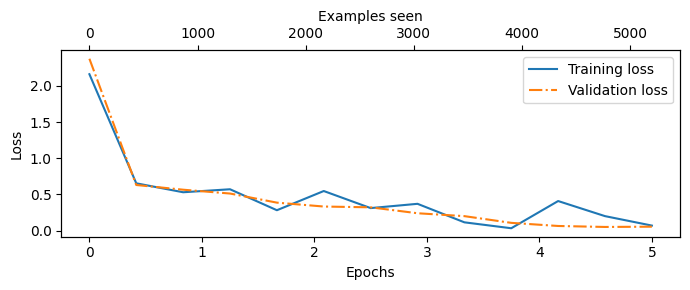

In [161]:

plot_values(epochs_tensor, example_seen_tensor, t_l, v_l)

**`> No sign for overfitting`**

#### Plot `Train accs`

In [162]:
train_accs, val_accs

([0.85, 0.875, 0.9, 0.975, 1.0], [0.75, 0.725, 0.925, 0.975, 0.975])

In [163]:
epochs_tensor = torch.linspace(0,num_epochs, len(train_accs))
example_seen_tensor = torch.linspace(0,example_seen, len(train_accs))

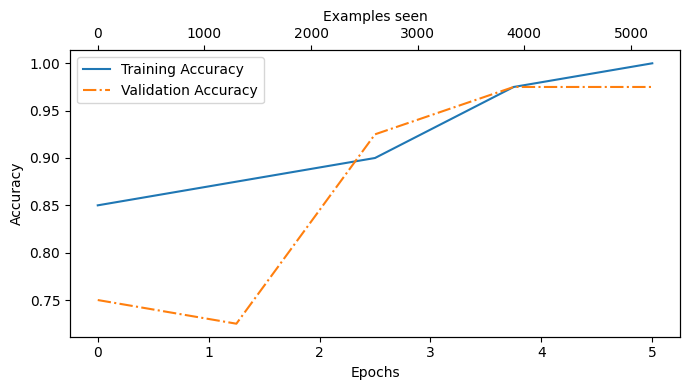

In [168]:
plot_values(epochs_tensor, example_seen_tensor, train_accs, val_accs , label="Accuracy")

## Calc the performance among all the batches

In [170]:
train_acc = calc_acc_loader(train_loader, gpt, device)
val_acc = calc_acc_loader(val_loader, gpt, device)
test_acc = calc_acc_loader(test_loader, gpt, device)


print(f"Training Accuracy After Training : {train_acc *100:.2f}%")
print(f"Validation Accuracy After Training : {val_acc *100:.2f}%")
print(f"Testing Accuracy After Training : {test_acc *100:.2f}%")

Training Accuracy After Training : 97.60%
Validation Accuracy After Training : 97.99%
Testing Accuracy After Training : 95.67%


# Use `Spam Classifier`

In [175]:
gpt.pos_emb.weight.shape

torch.Size([1024, 768])

In [177]:
def classify_review(text, model, tokenizer, device, max_length, pad_token =50256):
    model.eval()
    input_ids = tokenizer.encode(text)
    max_context_length = model.pos_emb.weight.shape[1]

    # take all inputs from 0 to min of max_length or max_context_length
    input_ids = input_ids[: min(max_length,max_context_length)]
    
    input_ids += [pad_token] * (max_length - len(input_ids))

    input_tensor =torch.tensor(input_ids, device=device).unsqueeze(0)


    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]
        predicted_label = torch.argmax(logits, dim=-1).item()

    return "spam" if predicted_label == 1 else "not spam"
    

### Test

In [ ]:
t2 = ("Is the Following text `spam`? Answer with 'yes' or 'no' :"
      "'You are a winner you have been specially "
      "Selected to receive $1000 cash or $2000 award'"
)

classify_review(t2, gpt, tokenizer, device, max_length=train_dataset.max_length)

'spam'

In [180]:
t3 = (
    "Hey, just wanted to check if we are still on "
    "for dinner tonight? let me know!"
)

classify_review(t3, gpt, tokenizer, device, max_length=train_dataset.max_length)

'not spam'

# Save the Model

In [181]:
torch.save(gpt.state_dict(), "review_classifier.pth")

# Load the Classifier model

In [182]:
model_state_dict = torch.load("review_classifier.pth" , map_location=device)
gpt.load_state_dict(model_state_dict)

<All keys matched successfully>